Imports successful!
Loading data from: /Users/tahmidawal/sparse2dense/0912-SpMV-CNN2D-SparseMatrices-nonorm/ml_data/order1_sine_1000samples.npz
File exists: True

Data loaded successfully!
Available keys: ['inputs', 'outputs', 'signal_infos', 'matrix_shape', 'matrix_nnz', 'n_samples', 'signal_length', 'p_order']
DATA DIMENSIONS AND PROPERTIES

📊 Dataset Overview:
   Number of samples: 1000
   Signal length: 1424
   Polynomial order: 1

📐 Array Shapes:
   Input shape:  (1000, 1424)
   Output shape: (1000, 1424)
   Signal infos: 1000 entries

🔢 Data Types:
   Inputs dtype:  float64
   Outputs dtype: float32

📈 Value Ranges:
   Input range:  [-1.737096, 1.768105]
   Output range: [-1.631283, 1.422549]

🎯 Matrix Properties:
   Matrix shape: [1424 1424]
   Non-zeros: 31,602
   Density: 1.56e-02

💾 Memory Usage:
   Inputs:  10.9 MB
   Outputs: 5.4 MB
   Total:   16.3 MB
Plotting random input vs output samples...


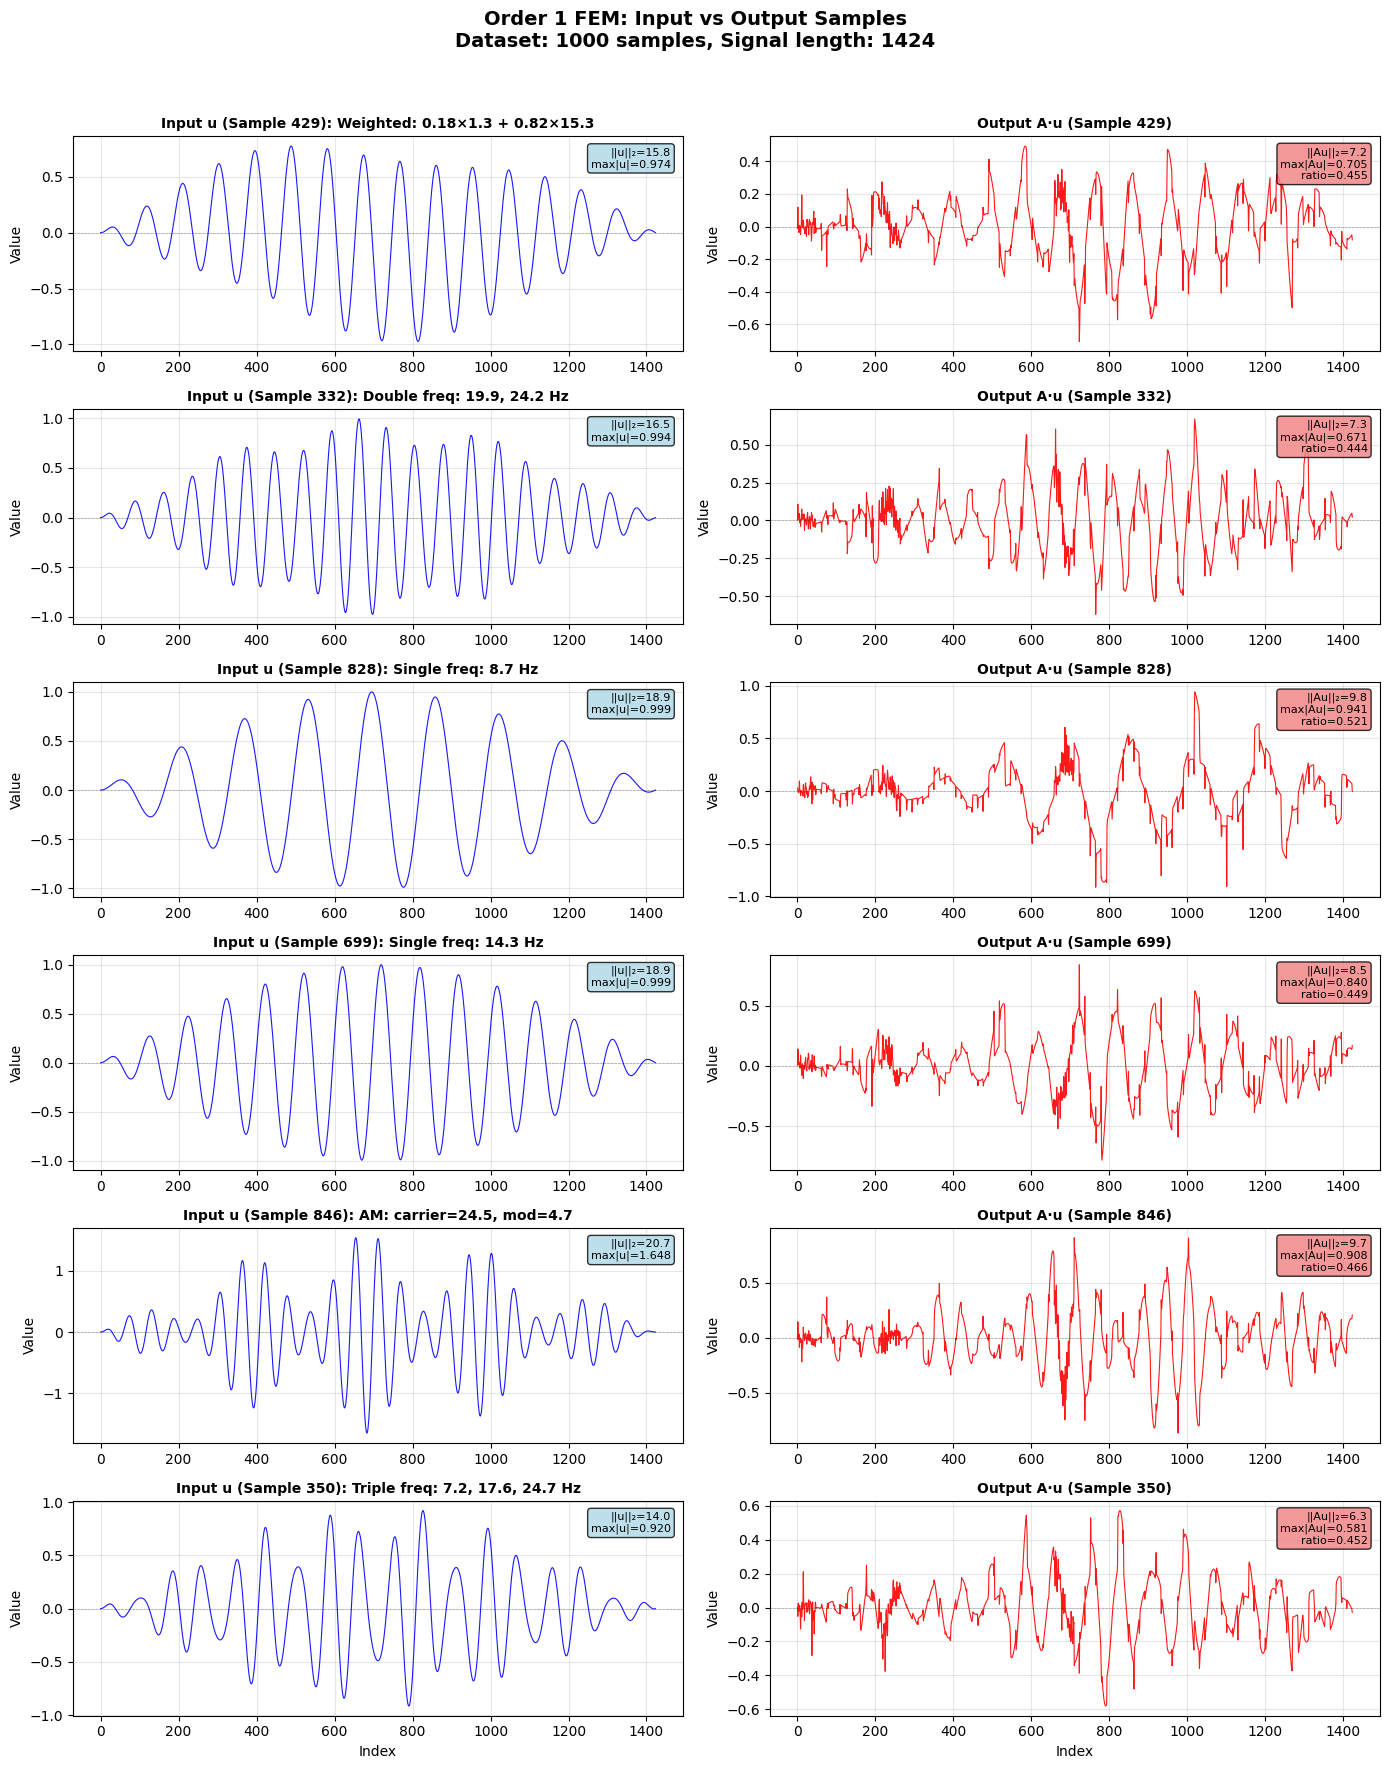

Plotted 6 random samples from the dataset.
Performing statistical analysis...


/var/folders/r5/l8vjf9nd79jcvn995635tyjh0000gn/T/ipykernel_87581/3404485873.py:218: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 2].boxplot(box_data, labels=box_labels)


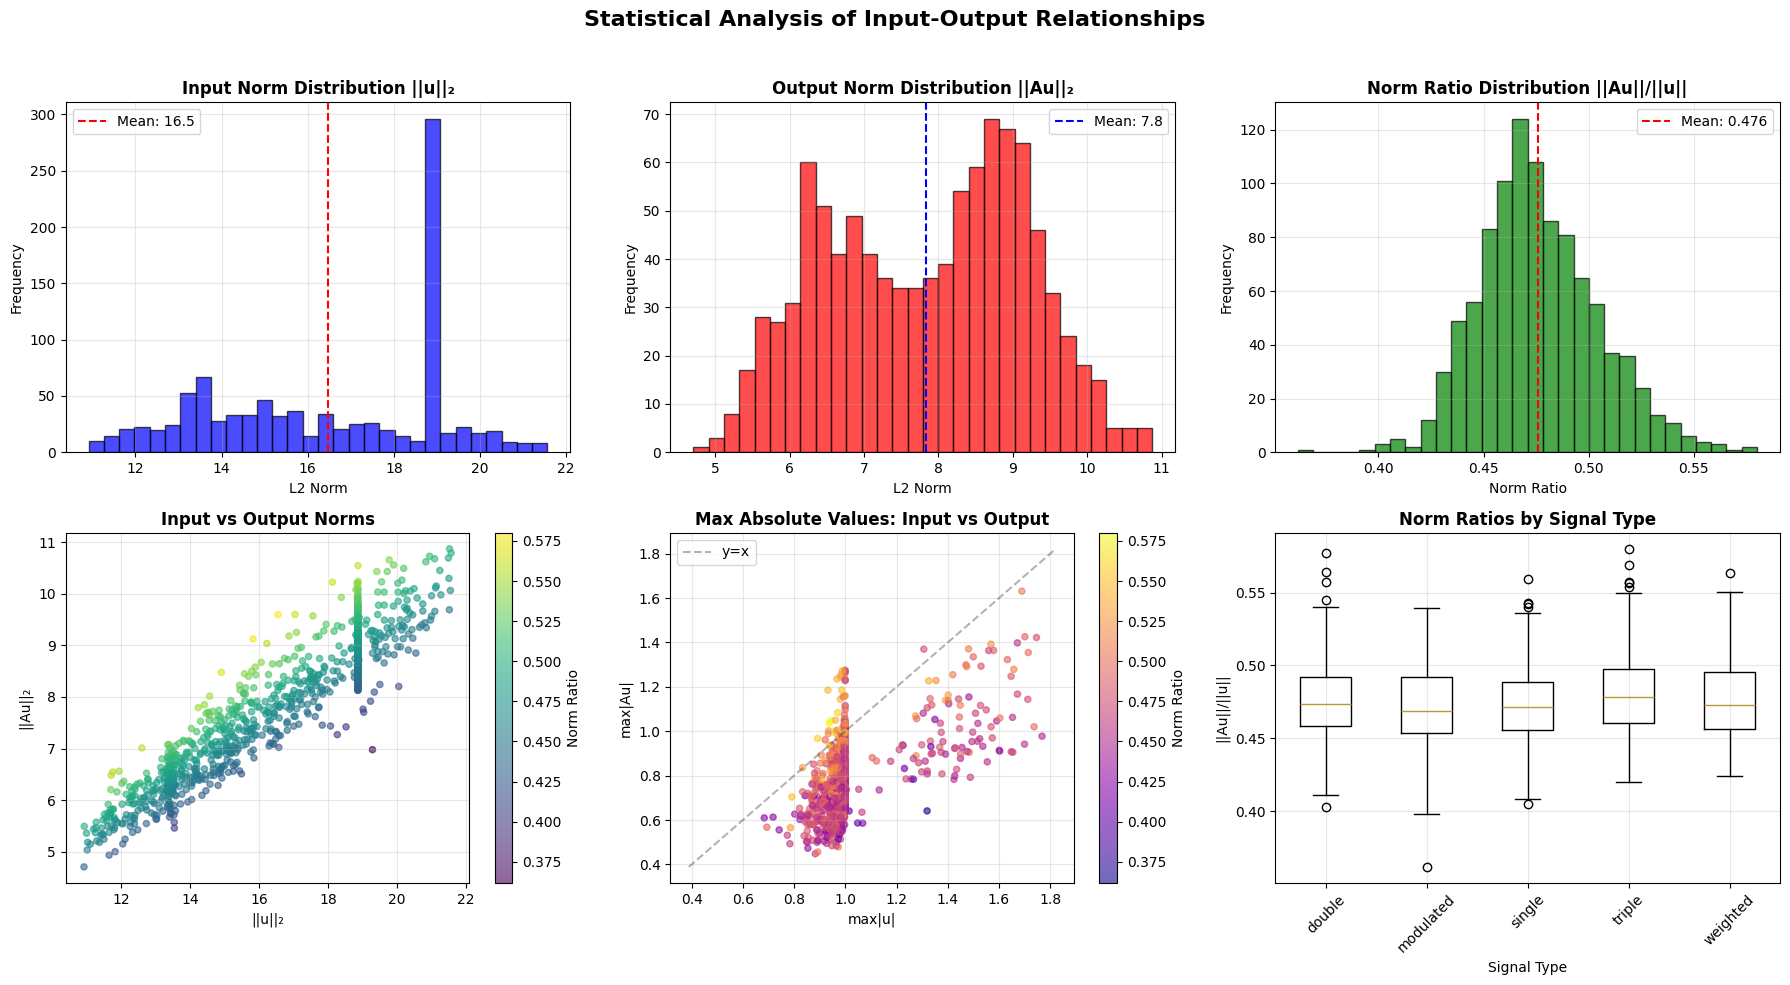


SUMMARY STATISTICS

📊 Norm Statistics:
   Input norms:  mean=16.472, std=2.662
   Output norms: mean=7.838, std=1.327
   Norm ratios:  mean=0.476, std=0.028

🎯 Max Value Statistics:
   Input max:  mean=1.017, std=0.157
   Output max: mean=0.796, std=0.172

🔗 Correlation Analysis:
   Correlation (norms): 0.935
   Correlation (max):   0.561
DATA QUALITY ASSESSMENT

🔍 Data Integrity:
   Input NaN values:  0
   Input Inf values:  0
   Output NaN values: 0
   Output Inf values: 0

✅ Quality Checks:
   No NaN/Inf in inputs:  True
   No NaN/Inf in outputs: True
   Input values reasonable:  True
   Output values reasonable: True
   Boundary conditions satisfied: True
   Unique input samples: 1000/1000 (100.0%)

🎯 Overall Data Quality Score: 100.0%
   ✅ Excellent! Data passes all quality checks.

📋 Dataset Summary:
   Ready for ML training: True
   Recommended preprocessing: Normalization (optional)
   Potential applications: CNN, RNN, Transformer models for SpMV approximation


In [3]:
# Cell 1: Imports and setup
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.sparse import csr_matrix
import seaborn as sns
from pathlib import Path

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

print("Imports successful!")

# Cell 2: Load data
# Load the training data
data_path = "/Users/tahmidawal/sparse2dense/0912-SpMV-CNN2D-SparseMatrices-nonorm/ml_data/order1_sine_1000samples.npz"

print(f"Loading data from: {data_path}")
print(f"File exists: {Path(data_path).exists()}")

# Load the data
data = np.load(data_path, allow_pickle=True)

# Extract components
inputs = data['inputs']  # Input signals (u)
outputs = data['outputs']  # Output signals (A·u)
signal_infos = data['signal_infos']  # Signal generation metadata
matrix_shape = data['matrix_shape']  # Sparse matrix shape
matrix_nnz = data['matrix_nnz']  # Number of non-zeros in matrix
n_samples = data['n_samples']  # Number of samples
signal_length = data['signal_length']  # Length of each signal
p_order = data['p_order']  # Polynomial order

print("\nData loaded successfully!")
print(f"Available keys: {list(data.keys())}")

# Cell 3: Data dimensions and properties
print("=" * 60)
print("DATA DIMENSIONS AND PROPERTIES")
print("=" * 60)

print(f"\n📊 Dataset Overview:")
print(f"   Number of samples: {n_samples}")
print(f"   Signal length: {signal_length}")
print(f"   Polynomial order: {p_order}")

print(f"\n📐 Array Shapes:")
print(f"   Input shape:  {inputs.shape}")
print(f"   Output shape: {outputs.shape}")
print(f"   Signal infos: {len(signal_infos)} entries")

print(f"\n🔢 Data Types:")
print(f"   Inputs dtype:  {inputs.dtype}")
print(f"   Outputs dtype: {outputs.dtype}")

print(f"\n📈 Value Ranges:")
print(f"   Input range:  [{np.min(inputs):.6f}, {np.max(inputs):.6f}]")
print(f"   Output range: [{np.min(outputs):.6f}, {np.max(outputs):.6f}]")

print(f"\n🎯 Matrix Properties:")
print(f"   Matrix shape: {matrix_shape}")
print(f"   Non-zeros: {matrix_nnz:,}")
print(f"   Density: {matrix_nnz/(matrix_shape[0]*matrix_shape[1]):.2e}")

print(f"\n💾 Memory Usage:")
print(f"   Inputs:  {inputs.nbytes / 1024**2:.1f} MB")
print(f"   Outputs: {outputs.nbytes / 1024**2:.1f} MB")
print(f"   Total:   {(inputs.nbytes + outputs.nbytes) / 1024**2:.1f} MB")

# Cell 4: Plot random input vs output samples
print("Plotting random input vs output samples...")

# Select random samples to plot
n_plots = 6
random_indices = np.random.choice(len(inputs), n_plots, replace=False)

fig, axes = plt.subplots(n_plots, 2, figsize=(14, 3 * n_plots))

for i, idx in enumerate(random_indices):
    input_signal = inputs[idx]
    output_signal = outputs[idx]
    info = signal_infos[idx]
    
    # Create title based on signal type
    if info['type'] == 'single':
        title = f"Single freq: {info['freq']:.1f} Hz"
    elif info['type'] == 'double':
        title = f"Double freq: {info['freq1']:.1f}, {info['freq2']:.1f} Hz"
    elif info['type'] == 'triple':
        title = f"Triple freq: {info['freq1']:.1f}, {info['freq2']:.1f}, {info['freq3']:.1f} Hz"
    elif info['type'] == 'weighted':
        title = f"Weighted: {info['w1']:.2f}×{info['freq1']:.1f} + {info['w2']:.2f}×{info['freq2']:.1f}"
    elif info['type'] == 'modulated':
        title = f"AM: carrier={info['carrier']:.1f}, mod={info['mod_freq']:.1f}"
    else:
        title = f"Type: {info['type']}"
    
    # Plot input
    axes[i, 0].plot(input_signal, 'b-', linewidth=0.8, alpha=0.9)
    axes[i, 0].set_title(f'Input u (Sample {idx}): {title}', fontsize=10, fontweight='bold')
    axes[i, 0].set_ylabel('Value')
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 0].axhline(y=0, color='k', linestyle='--', alpha=0.3, linewidth=0.5)
    
    # Add input statistics
    input_norm = np.linalg.norm(input_signal)
    input_max = np.max(np.abs(input_signal))
    axes[i, 0].text(0.98, 0.95, f'||u||₂={input_norm:.1f}\nmax|u|={input_max:.3f}', 
                   transform=axes[i, 0].transAxes, ha='right', va='top',
                   bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8), fontsize=8)
    
    # Plot output
    axes[i, 1].plot(output_signal, 'r-', linewidth=0.8, alpha=0.9)
    axes[i, 1].set_title(f'Output A·u (Sample {idx})', fontsize=10, fontweight='bold')
    axes[i, 1].set_ylabel('Value')
    axes[i, 1].grid(True, alpha=0.3)
    axes[i, 1].axhline(y=0, color='k', linestyle='--', alpha=0.3, linewidth=0.5)
    
    # Add output statistics
    output_norm = np.linalg.norm(output_signal)
    output_max = np.max(np.abs(output_signal))
    norm_ratio = output_norm / (input_norm + 1e-10)
    axes[i, 1].text(0.98, 0.95, f'||Au||₂={output_norm:.1f}\nmax|Au|={output_max:.3f}\nratio={norm_ratio:.3f}', 
                   transform=axes[i, 1].transAxes, ha='right', va='top',
                   bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.8), fontsize=8)
    
    # Add x-label only to bottom plots
    if i == n_plots - 1:
        axes[i, 0].set_xlabel('Index')
        axes[i, 1].set_xlabel('Index')

plt.suptitle('Order 1 FEM: Input vs Output Samples\n'
             f'Dataset: {n_samples} samples, Signal length: {signal_length}', 
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print(f"Plotted {n_plots} random samples from the dataset.")

# Cell 5: Statistical analysis
print("Performing statistical analysis...")

# Calculate norms and statistics
input_norms = np.linalg.norm(inputs, axis=1)
output_norms = np.linalg.norm(outputs, axis=1)
norm_ratios = output_norms / (input_norms + 1e-10)

input_max = np.max(np.abs(inputs), axis=1)
output_max = np.max(np.abs(outputs), axis=1)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Input norm distribution
axes[0, 0].hist(input_norms, bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[0, 0].axvline(np.mean(input_norms), color='red', linestyle='--', 
                  label=f'Mean: {np.mean(input_norms):.1f}')
axes[0, 0].set_title('Input Norm Distribution ||u||₂', fontweight='bold')
axes[0, 0].set_xlabel('L2 Norm')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Output norm distribution
axes[0, 1].hist(output_norms, bins=30, alpha=0.7, color='red', edgecolor='black')
axes[0, 1].axvline(np.mean(output_norms), color='blue', linestyle='--', 
                  label=f'Mean: {np.mean(output_norms):.1f}')
axes[0, 1].set_title('Output Norm Distribution ||Au||₂', fontweight='bold')
axes[0, 1].set_xlabel('L2 Norm')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Norm ratio distribution
axes[0, 2].hist(norm_ratios, bins=30, alpha=0.7, color='green', edgecolor='black')
axes[0, 2].axvline(np.mean(norm_ratios), color='red', linestyle='--', 
                  label=f'Mean: {np.mean(norm_ratios):.3f}')
axes[0, 2].set_title('Norm Ratio Distribution ||Au||/||u||', fontweight='bold')
axes[0, 2].set_xlabel('Norm Ratio')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 4. Input vs Output norms scatter
axes[1, 0].scatter(input_norms, output_norms, alpha=0.6, s=20, c=norm_ratios, cmap='viridis')
axes[1, 0].set_title('Input vs Output Norms', fontweight='bold')
axes[1, 0].set_xlabel('||u||₂')
axes[1, 0].set_ylabel('||Au||₂')
axes[1, 0].grid(True, alpha=0.3)
cbar1 = plt.colorbar(axes[1, 0].collections[0], ax=axes[1, 0])
cbar1.set_label('Norm Ratio')

# 5. Max values scatter
axes[1, 1].scatter(input_max, output_max, alpha=0.6, s=20, c=norm_ratios, cmap='plasma')
axes[1, 1].set_title('Max Absolute Values: Input vs Output', fontweight='bold')
axes[1, 1].set_xlabel('max|u|')
axes[1, 1].set_ylabel('max|Au|')
axes[1, 1].grid(True, alpha=0.3)
# Add diagonal line for reference
lims = [min(axes[1, 1].get_xlim()[0], axes[1, 1].get_ylim()[0]), 
        max(axes[1, 1].get_xlim()[1], axes[1, 1].get_ylim()[1])]
axes[1, 1].plot(lims, lims, 'k--', alpha=0.3, label='y=x')
axes[1, 1].legend()
cbar2 = plt.colorbar(axes[1, 1].collections[0], ax=axes[1, 1])
cbar2.set_label('Norm Ratio')

# 6. Signal type vs norm ratio
signal_type_ratios = {}
for i, info in enumerate(signal_infos):
    t = info['type']
    if t not in signal_type_ratios:
        signal_type_ratios[t] = []
    signal_type_ratios[t].append(norm_ratios[i])

# Box plot of norm ratios by signal type
box_data = [signal_type_ratios[t] for t in sorted(signal_type_ratios.keys())]
box_labels = sorted(signal_type_ratios.keys())
axes[1, 2].boxplot(box_data, labels=box_labels)
axes[1, 2].set_title('Norm Ratios by Signal Type', fontweight='bold')
axes[1, 2].set_xlabel('Signal Type')
axes[1, 2].set_ylabel('||Au||/||u||')
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].tick_params(axis='x', rotation=45)

plt.suptitle('Statistical Analysis of Input-Output Relationships', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Print summary statistics
print("\n" + "=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)
print(f"\n📊 Norm Statistics:")
print(f"   Input norms:  mean={np.mean(input_norms):.3f}, std={np.std(input_norms):.3f}")
print(f"   Output norms: mean={np.mean(output_norms):.3f}, std={np.std(output_norms):.3f}")
print(f"   Norm ratios:  mean={np.mean(norm_ratios):.3f}, std={np.std(norm_ratios):.3f}")

print(f"\n🎯 Max Value Statistics:")
print(f"   Input max:  mean={np.mean(input_max):.3f}, std={np.std(input_max):.3f}")
print(f"   Output max: mean={np.mean(output_max):.3f}, std={np.std(output_max):.3f}")

print(f"\n🔗 Correlation Analysis:")
corr_norms = np.corrcoef(input_norms, output_norms)[0, 1]
corr_max = np.corrcoef(input_max, output_max)[0, 1]
print(f"   Correlation (norms): {corr_norms:.3f}")
print(f"   Correlation (max):   {corr_max:.3f}")

# Cell 6: Data quality assessment
print("=" * 60)
print("DATA QUALITY ASSESSMENT")
print("=" * 60)

# Check for NaN or infinite values
input_nan = np.isnan(inputs).sum()
input_inf = np.isinf(inputs).sum()
output_nan = np.isnan(outputs).sum()
output_inf = np.isinf(outputs).sum()

print(f"\n🔍 Data Integrity:")
print(f"   Input NaN values:  {input_nan}")
print(f"   Input Inf values:  {input_inf}")
print(f"   Output NaN values: {output_nan}")
print(f"   Output Inf values: {output_inf}")

# Check data ranges
input_range_ok = np.all(np.abs(inputs) <= 10)  # Reasonable range
output_range_ok = np.all(np.abs(outputs) <= 10)  # Reasonable range

print(f"\n✅ Quality Checks:")
print(f"   No NaN/Inf in inputs:  {input_nan == 0 and input_inf == 0}")
print(f"   No NaN/Inf in outputs: {output_nan == 0 and output_inf == 0}")
print(f"   Input values reasonable:  {input_range_ok}")
print(f"   Output values reasonable: {output_range_ok}")
print(f"   Boundary conditions satisfied: {np.max(np.abs(inputs[:, [0, -1]])) < 1e-10}")

# Check for duplicate samples
unique_inputs = len(np.unique(inputs.reshape(inputs.shape[0], -1), axis=0))
print(f"   Unique input samples: {unique_inputs}/{len(inputs)} ({100*unique_inputs/len(inputs):.1f}%)")

# Overall assessment
all_checks = [
    input_nan == 0 and input_inf == 0,
    output_nan == 0 and output_inf == 0,
    input_range_ok,
    output_range_ok,
    np.max(np.abs(inputs[:, [0, -1]])) < 1e-10,
    unique_inputs == len(inputs)
]

quality_score = sum(all_checks) / len(all_checks) * 100
print(f"\n🎯 Overall Data Quality Score: {quality_score:.1f}%")

if quality_score == 100:
    print("   ✅ Excellent! Data passes all quality checks.")
elif quality_score >= 80:
    print("   ⚠️  Good, but some minor issues detected.")
else:
    print("   ❌ Issues detected that may affect training.")

print(f"\n📋 Dataset Summary:")
print(f"   Ready for ML training: {quality_score >= 80}")
print(f"   Recommended preprocessing: Normalization (optional)")
print(f"   Potential applications: CNN, RNN, Transformer models for SpMV approximation")